Install dependencies and import libraries

In [1]:
!pip install -q ultralytics gdown pyyaml matplotlib pandas pillow

import os
import json
import math
import random
import shutil
import zipfile
from pathlib import Path
from collections import Counter

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import gdown
from ultralytics import YOLO

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


Check GPU status

In [2]:
!nvidia-smi

Sun Apr  5 09:43:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Download custom dataset zip from Google Drive

In [3]:
DRIVE_SHARE_LINK = "https://drive.google.com/file/d/1ksSmXrvPLseH7Pf9_TgpfZTUNaYa9Av1/view?usp=drive_link"

ZIP_PATH = "/content/construction_ppe_dataset.zip"

gdown.download(
    DRIVE_SHARE_LINK,
    ZIP_PATH,
    quiet=False,
    fuzzy=True
)

print("Downloaded zip path:", ZIP_PATH)
print("Zip exists:", Path(ZIP_PATH).exists())
print("Zip size (MB):", round(Path(ZIP_PATH).stat().st_size / (1024 * 1024), 2))

Downloading...
From (original): https://drive.google.com/uc?id=1ksSmXrvPLseH7Pf9_TgpfZTUNaYa9Av1
From (redirected): https://drive.google.com/uc?id=1ksSmXrvPLseH7Pf9_TgpfZTUNaYa9Av1&confirm=t&uuid=090218fd-fbee-40e4-b4c5-8eadfeff0781
To: /content/construction_ppe_dataset.zip
100%|██████████| 210M/210M [00:04<00:00, 49.4MB/s]

Downloaded zip path: /content/construction_ppe_dataset.zip
Zip exists: True
Zip size (MB): 200.09


Extract dataset archive

In [4]:
EXTRACT_DIR = Path("/content/datasets/construction_ppe_dataset")

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)

Extracted to: /content/datasets/construction_ppe_dataset


Auto-detect YOLO dataset root


*   finds the folder that contains the YOLO structure (images/train, labels/train, etc.).em



In [5]:
def find_dataset_root(base_dir):
    base_dir = Path(base_dir)
    candidates = []

    for p in [base_dir] + [x for x in base_dir.rglob("*") if x.is_dir()]:
        if (p / "images" / "train").exists() and (p / "labels" / "train").exists():
            candidates.append(p)

    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda x: len(x.parts))
    return candidates[0]

DATASET_ROOT = find_dataset_root(EXTRACT_DIR)
assert DATASET_ROOT is not None, "Could not find YOLO dataset structure inside the extracted zip."

print("Detected DATASET_ROOT:", DATASET_ROOT)

for split in ["train", "val", "test"]:
    img_dir = DATASET_ROOT / "images" / split
    lbl_dir = DATASET_ROOT / "labels" / split
    print(f"\n{split}:")
    print(" images exists:", img_dir.exists(), img_dir)
    print(" labels exists:", lbl_dir.exists(), lbl_dir)

Detected DATASET_ROOT: /content/datasets/construction_ppe_dataset/construction_custom_final

train:
 images exists: True /content/datasets/construction_ppe_dataset/construction_custom_final/images/train
 labels exists: True /content/datasets/construction_ppe_dataset/construction_custom_final/labels/train

val:
 images exists: True /content/datasets/construction_ppe_dataset/construction_custom_final/images/val
 labels exists: True /content/datasets/construction_ppe_dataset/construction_custom_final/labels/val

test:
 images exists: True /content/datasets/construction_ppe_dataset/construction_custom_final/images/test
 labels exists: True /content/datasets/construction_ppe_dataset/construction_custom_final/labels/test


Create YOLO data.yaml


*   Creates the dataset config file used by Ultralytics.



In [6]:
CLASS_NAMES = {
    0: "person",
    1: "helmet",
    2: "vest"
}

data_yaml = {
    "path": str(DATASET_ROOT),
    "train": "images/train",
    "val": "images/val",
    "names": CLASS_NAMES
}

if (DATASET_ROOT / "images" / "test").exists():
    data_yaml["test"] = "images/test"

YAML_PATH = "/content/construction_ppe.yaml"

with open(YAML_PATH, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(open(YAML_PATH, "r").read())

path: /content/datasets/construction_ppe_dataset/construction_custom_final
train: images/train
val: images/val
names:
  0: person
  1: helmet
  2: vest
test: images/test



Audit dataset labels and structure


*   Checks for missing labels, orphan labels, invalid rows, and class IDs.



In [7]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
VALID_CLASSES = {0, 1, 2}

def get_image_files(folder):
    folder = Path(folder)
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS])

def audit_split(dataset_root, split):
    img_dir = Path(dataset_root) / "images" / split
    lbl_dir = Path(dataset_root) / "labels" / split

    images = get_image_files(img_dir)
    labels = sorted(lbl_dir.glob("*.txt")) if lbl_dir.exists() else []

    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}

    missing_labels = sorted(img_stems - lbl_stems)
    orphan_labels = sorted(lbl_stems - img_stems)

    invalid_rows = []
    class_counts = Counter()

    for label_path in labels:
        with open(label_path, "r") as f:
            lines = [ln.strip() for ln in f.readlines() if ln.strip()]

        for line_no, line in enumerate(lines, start=1):
            parts = line.split()
            if len(parts) != 5:
                invalid_rows.append((label_path.name, line_no, "Expected 5 values"))
                continue

            try:
                cls_id = int(float(parts[0]))
                coords = list(map(float, parts[1:]))
            except Exception:
                invalid_rows.append((label_path.name, line_no, "Non-numeric value"))
                continue

            if cls_id not in VALID_CLASSES:
                invalid_rows.append((label_path.name, line_no, f"Invalid class id: {cls_id}"))

            if not all(0.0 <= v <= 1.0 for v in coords):
                invalid_rows.append((label_path.name, line_no, f"Coordinates out of [0,1]: {coords}"))

            class_counts[cls_id] += 1

    return {
        "split": split,
        "num_images": len(images),
        "num_labels": len(labels),
        "missing_labels": missing_labels,
        "orphan_labels": orphan_labels,
        "invalid_rows": invalid_rows,
        "class_counts": class_counts,
    }

AUDIT_SUMMARY = {}
for split in ["train", "val", "test"]:
    if (DATASET_ROOT / "images" / split).exists():
        AUDIT_SUMMARY[split] = audit_split(DATASET_ROOT, split)

for split, s in AUDIT_SUMMARY.items():
    print(f"\n--- {split.upper()} ---")
    print("images:", s["num_images"])
    print("label files:", s["num_labels"])
    print("class counts:", dict(s["class_counts"]))
    print("missing labels:", len(s["missing_labels"]))
    print("orphan labels:", len(s["orphan_labels"]))
    print("invalid rows:", len(s["invalid_rows"]))

    if s["missing_labels"][:5]:
        print("sample missing labels:", s["missing_labels"][:5])
    if s["orphan_labels"][:5]:
        print("sample orphan labels:", s["orphan_labels"][:5])
    if s["invalid_rows"][:5]:
        print("sample invalid rows:", s["invalid_rows"][:5])

assert "train" in AUDIT_SUMMARY and "val" in AUDIT_SUMMARY, "You need at least train and val splits."
print("\nDataset audit finished.")


--- TRAIN ---
images: 1093
label files: 1093
class counts: {1: 2891, 0: 3188, 2: 1495}
missing labels: 0
orphan labels: 0
invalid rows: 0

--- VAL ---
images: 141
label files: 141
class counts: {1: 372, 0: 419, 2: 190}
missing labels: 0
orphan labels: 0
invalid rows: 0

--- TEST ---
images: 138
label files: 138
class counts: {1: 369, 0: 402, 2: 187}
missing labels: 0
orphan labels: 0
invalid rows: 0

Dataset audit finished.


Dataset statistics and class balance


*   Summarizes image counts and object counts by split



,num_images,person,helmet,vest
split,,,,
train,1093,3188,2891,1495
val,141,419,372,190
test,138,402,369,187


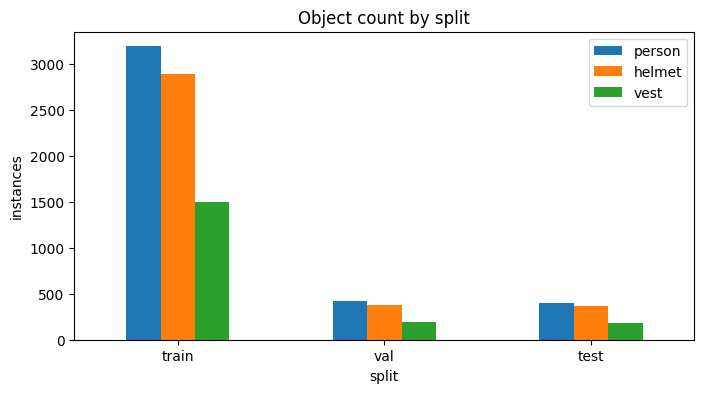

Saved dataset statistics to /content/dataset_stats.csv


In [8]:
rows = []
for split, s in AUDIT_SUMMARY.items():
    rows.append({
        "split": split,
        "num_images": s["num_images"],
        "person": s["class_counts"].get(0, 0),
        "helmet": s["class_counts"].get(1, 0),
        "vest": s["class_counts"].get(2, 0),
    })

stats_df = pd.DataFrame(rows).set_index("split")
display(stats_df)

ax = stats_df[["person", "helmet", "vest"]].plot(kind="bar", figsize=(8, 4))
ax.set_title("Object count by split")
ax.set_ylabel("instances")
plt.xticks(rotation=0)
plt.show()

stats_df.to_csv("/content/dataset_stats.csv")
print("Saved dataset statistics to /content/dataset_stats.csv")

Visual sanity check of annotations

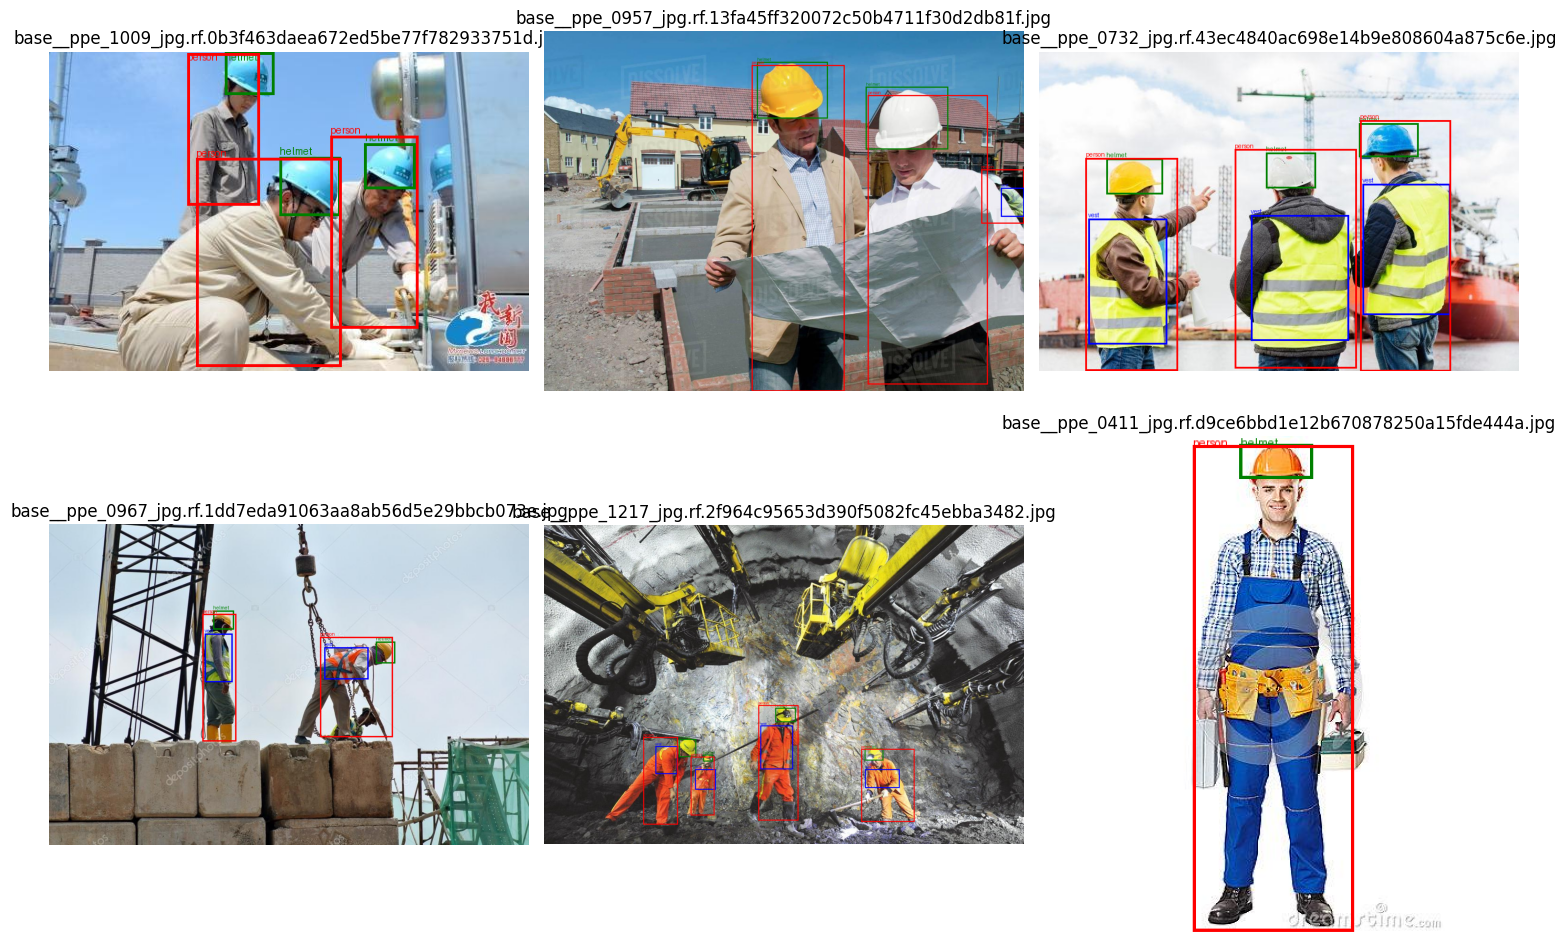

In [9]:
def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    x1 = (xc - w / 2) * img_w
    y1 = (yc - h / 2) * img_h
    x2 = (xc + w / 2) * img_w
    y2 = (yc + h / 2) * img_h
    return x1, y1, x2, y2

def load_yolo_labels(label_path):
    anns = []
    label_path = Path(label_path)
    if not label_path.exists():
        return anns

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id, xc, yc, w, h = parts
            anns.append((int(float(cls_id)), float(xc), float(yc), float(w), float(h)))
    return anns

def show_random_samples(dataset_root, split="train", n=6):
    image_files = get_image_files(Path(dataset_root) / "images" / split)
    chosen = random.sample(image_files, min(n, len(image_files)))

    cols = 3
    rows = math.ceil(len(chosen) / cols)
    plt.figure(figsize=(15, 5 * rows))

    color_map = {0: "red", 1: "green", 2: "blue"}

    for idx, img_path in enumerate(chosen, start=1):
        img = Image.open(img_path).convert("RGB")
        draw = ImageDraw.Draw(img)
        img_w, img_h = img.size

        label_path = Path(dataset_root) / "labels" / split / f"{img_path.stem}.txt"
        anns = load_yolo_labels(label_path)

        for cls_id, xc, yc, bw, bh in anns:
            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, bw, bh, img_w, img_h)
            color = color_map[cls_id]
            draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
            draw.text((x1, max(0, y1 - 12)), CLASS_NAMES[cls_id], fill=color)

        plt.subplot(rows, cols, idx)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)

    plt.tight_layout()
    plt.show()

show_random_samples(DATASET_ROOT, split="train", n=6)

Train the YOLO model

In [11]:
from pathlib import Path
from ultralytics import YOLO

MODEL_NAME = "yolov8m.pt"
IMGSZ = 896
EPOCHS = 50
PATIENCE = 8
RUN_NAME = "yolov8m_ppe_v1_es"

model = YOLO(MODEL_NAME)

train_results = model.train(
    data=YAML_PATH,
    epochs=EPOCHS,          # max training limit for this Colab session
    patience=PATIENCE,      # stop early if val does not improve
    imgsz=IMGSZ,
    batch=-1,               # automatic safe batch sizing
    device=0,
    workers=4,
    optimizer="auto",
    pretrained=True,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    cache="disk",
    seed=42,
    deterministic=False,

    hsv_h=0.015,
    hsv_s=0.50,
    hsv_v=0.35,
    degrees=3.0,
    translate=0.10,
    scale=0.40,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.50,
    mosaic=1.0,
    mixup=0.0,

    project="/content/runs/detect",
    name=RUN_NAME,
    exist_ok=True,
    plots=False,
    save=True,
    verbose=True
)

TRAIN_RUN_DIR = Path(train_results.save_dir)
BEST_WEIGHTS = TRAIN_RUN_DIR / "weights" / "best.pt"
LAST_WEIGHTS = TRAIN_RUN_DIR / "weights" / "last.pt"

print("Run directory:", TRAIN_RUN_DIR)
print("Best weights:", BEST_WEIGHTS)
print("Last weights:", LAST_WEIGHTS)
print("Max epochs:", EPOCHS)
print("Early stopping patience:", PATIENCE)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/construction_ppe.yaml, degrees=3.0, deterministic=False, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.35, imgsz=896, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_ppe_v1_es, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=8, pers

Validate the best checkpoint on the validation split

In [12]:
DEVICE_FOR_EVAL = 0 if torch.cuda.is_available() else "cpu"
EVAL_BATCH = 4

best_model = YOLO(str(BEST_WEIGHTS))

val_metrics = best_model.val(
    data=YAML_PATH,
    split="val",
    imgsz=IMGSZ,
    batch=EVAL_BATCH,
    device=DEVICE_FOR_EVAL,
    plots=True,
    save_json=False,
    project="/content/runs/detect",
    name=f"{RUN_NAME}_val",
    exist_ok=True,
    verbose=True
)

VAL_RUN_DIR = Path(val_metrics.save_dir)
print("Validation artifacts saved to:", VAL_RUN_DIR)
print("Validation overall metrics:")
print(val_metrics.results_dict)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 64.6±74.0 MB/s, size: 306.2 KB)
val: Scanning /content/datasets/construction_ppe_dataset/construction_custom_final/labels/val.cache... 141 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 53.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 5.6it/s 6.4s
                   all        141        981      0.912      0.905      0.944      0.571
                person        140        419       0.91      0.919      0.945      0.571
                helmet        136        372      0.923      0.907      0.937       0.55
                  vest         76        190      0.904       0.89       0.95      0.592
Speed: 2.6ms preprocess, 34.6ms inference, 0.0ms loss, 1.4ms postprocess per image
Resul

Evaluates the final checkpoint on unseen test data

In [13]:
test_metrics = None
TEST_RUN_DIR = None

if (DATASET_ROOT / "images" / "test").exists():
    test_metrics = best_model.val(
        data=YAML_PATH,
        split="test",
        imgsz=IMGSZ,
        batch=EVAL_BATCH,
        device=DEVICE_FOR_EVAL,
        plots=True,
        save_json=False,
        project="/content/runs/detect",
        name=f"{RUN_NAME}_test",
        exist_ok=True,
        verbose=True
    )
    TEST_RUN_DIR = Path(test_metrics.save_dir)
    print("Test artifacts saved to:", TEST_RUN_DIR)
    print("Test overall metrics:")
    print(test_metrics.results_dict)
else:
    print("No test split found. Skipping test evaluation.")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 35.5±45.2 MB/s, size: 224.7 KB)
val: Scanning /content/datasets/construction_ppe_dataset/construction_custom_final/labels/test... 138 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 138/138 398.6it/s 0.3s
val: New cache created: /content/datasets/construction_ppe_dataset/construction_custom_final/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 4.9it/s 7.1s
                   all        138        958      0.955      0.878      0.946      0.569
                person        136        402      0.956      0.888      0.942       0.55
                helmet        134        369      0.977      0.918      0.966      0.576
                  vest         71        187      0.931      0.829      0.928      0.581
Speed: 2.9ms preprocess, 39.3ms inference, 0.0ms loss, 1.3ms pos

Build clean evaluation tables

In [14]:
def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

# Make CLASS_NAMES robust whether it is a dict like {0:"person",1:"helmet",2:"vest"}
# or a list like ["person","helmet","vest"]
if isinstance(CLASS_NAMES, dict):
    class_ids = sorted(CLASS_NAMES.keys())
    class_names_ordered = [CLASS_NAMES[i] for i in class_ids]
else:
    class_names_ordered = list(CLASS_NAMES)
    class_ids = list(range(len(class_names_ordered)))

def overall_metrics_row(metrics, split_name):
    d = metrics.results_dict
    return {
        "split": split_name,
        "precision": safe_float(d.get("metrics/precision(B)", np.nan)),
        "recall": safe_float(d.get("metrics/recall(B)", np.nan)),
        "mAP50": safe_float(d.get("metrics/mAP50(B)", np.nan)),
        "mAP50-95": safe_float(d.get("metrics/mAP50-95(B)", np.nan)),
        "fitness": safe_float(d.get("fitness", np.nan)),
        "preprocess_ms": safe_float(metrics.speed.get("preprocess", np.nan)),
        "inference_ms": safe_float(metrics.speed.get("inference", np.nan)),
        "postprocess_ms": safe_float(metrics.speed.get("postprocess", np.nan)),
    }

def build_per_class_df(metrics, class_ids, class_names_ordered):
    rows = []
    for cls_id, cls_name in zip(class_ids, class_names_ordered):
        try:
            precision, recall, ap50, ap = metrics.class_result(cls_id)
        except Exception:
            precision, recall, ap50, ap = [np.nan, np.nan, np.nan, np.nan]

        rows.append({
            "class_id": cls_id,
            "class_name": cls_name,
            "precision": safe_float(precision),
            "recall": safe_float(recall),
            "mAP50": safe_float(ap50),
            "mAP50-95": safe_float(ap),
        })
    return pd.DataFrame(rows)

# Overall metrics table
overall_rows = [overall_metrics_row(val_metrics, "val")]
if test_metrics is not None:
    overall_rows.append(overall_metrics_row(test_metrics, "test"))

overall_metrics_df = pd.DataFrame(overall_rows)
display(
    overall_metrics_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "mAP50": "{:.4f}",
        "mAP50-95": "{:.4f}",
        "fitness": "{:.4f}",
        "preprocess_ms": "{:.2f}",
        "inference_ms": "{:.2f}",
        "postprocess_ms": "{:.2f}",
    })
)

# Per-class validation metrics
val_per_class_df = build_per_class_df(val_metrics, class_ids, class_names_ordered)
display(
    val_per_class_df.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "mAP50": "{:.4f}",
        "mAP50-95": "{:.4f}",
    })
)

# Save validation outputs
overall_metrics_df.to_csv("/content/evaluation_overall.csv", index=False)
val_per_class_df.to_csv("/content/evaluation_per_class_val.csv", index=False)

# Per-class test metrics
if test_metrics is not None:
    test_per_class_df = build_per_class_df(test_metrics, class_ids, class_names_ordered)
    display(
        test_per_class_df.style.format({
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "mAP50": "{:.4f}",
            "mAP50-95": "{:.4f}",
        })
    )
    test_per_class_df.to_csv("/content/evaluation_per_class_test.csv", index=False)

print("Saved evaluation CSV files to /content")

,split,precision,recall,mAP50,mAP50-95,fitness,preprocess_ms,inference_ms,postprocess_ms
0,val,0.9125,0.9054,0.9441,0.5712,0.5712,2.57,34.58,1.42
1,test,0.9545,0.8783,0.9455,0.5688,0.5688,2.93,39.29,1.25


,class_id,class_name,precision,recall,mAP50,mAP50-95
0,0,person,0.9102,0.9189,0.9451,0.5707
1,1,helmet,0.9234,0.9071,0.9372,0.5505
2,2,vest,0.9038,0.8903,0.9500,0.5925


,class_id,class_name,precision,recall,mAP50,mAP50-95
0,0,person,0.9556,0.8881,0.9420,0.5500
1,1,helmet,0.9769,0.9179,0.9664,0.5758
2,2,vest,0.9310,0.8289,0.9282,0.5807


Saved evaluation CSV files to /content


Plot training curves and loss curves inline

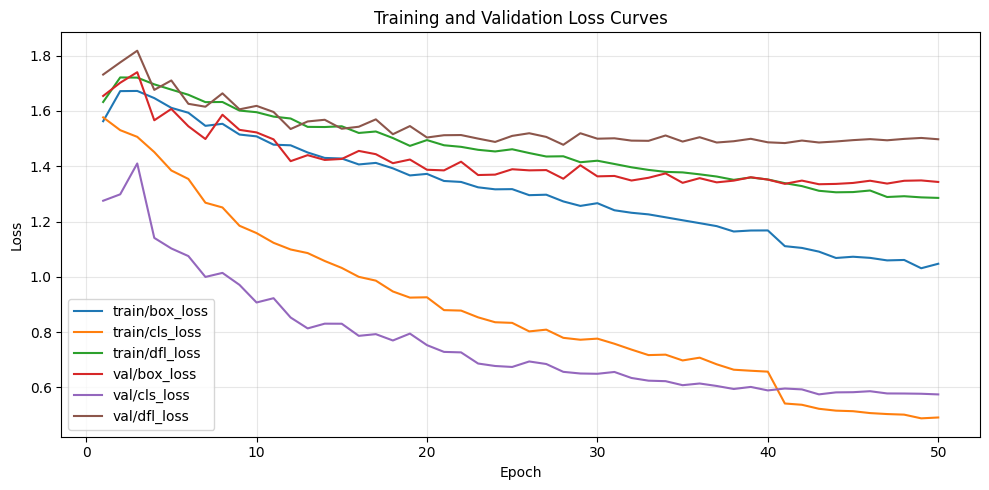

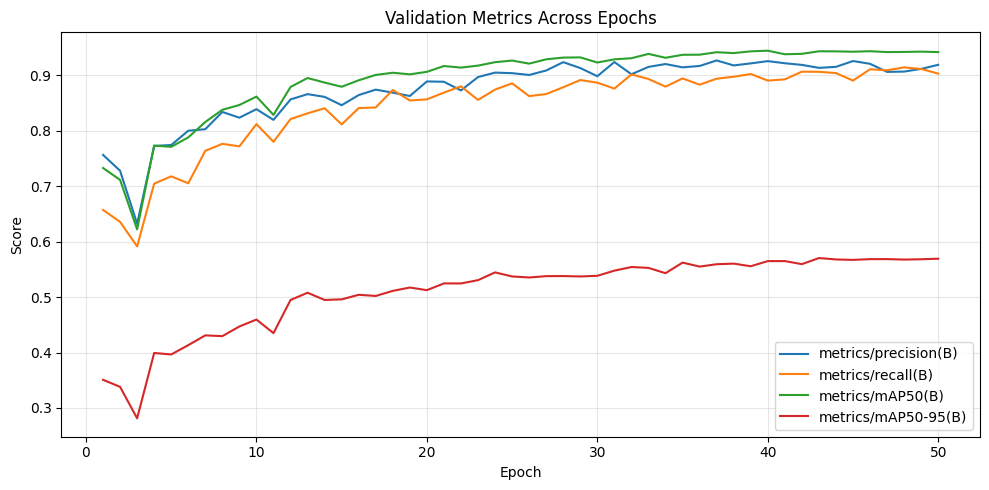

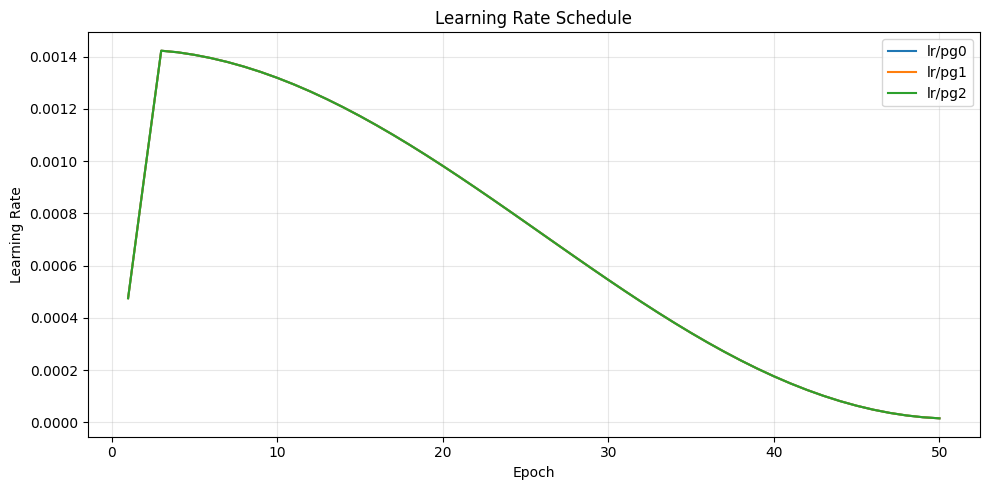

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,4001.17,1.06859,0.50752,1.31211,0.92078,0.91097,0.94351,0.56844,1.34745,0.58656,1.49782,0.000049,0.000049,0.000049
46,47,4086.40,1.05945,0.50400,1.28859,0.90621,0.90915,0.94195,0.56852,1.33716,0.57848,1.49363,0.000037,0.000037,0.000037
47,48,4174.42,1.06103,0.50188,1.29144,0.90677,0.91434,0.94219,0.56766,1.34728,0.57822,1.49867,0.000027,0.000027,0.000027
48,49,4260.64,1.03108,0.48850,1.28728,0.91164,0.91146,0.94272,0.56825,1.34853,0.57739,1.50211,0.000020,0.000020,0.000020
49,50,4345.09,1.04729,0.49157,1.28536,0.91898,0.90314,0.94195,0.56923,1.34300,0.57501,1.49736,0.000016,0.000016,0.000016


In [15]:
results_csv = TRAIN_RUN_DIR / "results.csv"
results_df = pd.read_csv(results_csv)
results_df.columns = [c.strip() for c in results_df.columns]

x = results_df["epoch"] if "epoch" in results_df.columns else np.arange(1, len(results_df) + 1)

def plot_columns(df, x, candidate_cols, title, ylabel):
    cols = [c for c in candidate_cols if c in df.columns]
    if not cols:
        print(f"Skipped '{title}' because none of these columns were found:\n{candidate_cols}")
        return

    plt.figure(figsize=(10, 5))
    for c in cols:
        plt.plot(x, df[c], label=c)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_columns(
    results_df,
    x,
    ["train/box_loss", "train/cls_loss", "train/dfl_loss",
     "val/box_loss", "val/cls_loss", "val/dfl_loss"],
    "Training and Validation Loss Curves",
    "Loss"
)

plot_columns(
    results_df,
    x,
    ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"],
    "Validation Metrics Across Epochs",
    "Score"
)

lr_cols = [c for c in results_df.columns if c.startswith("lr/")]
plot_columns(
    results_df,
    x,
    lr_cols,
    "Learning Rate Schedule",
    "Learning Rate"
)

display(results_df.tail())

Displays Ultralytics-generated figures like PR curve, F1 curve, confusion matrix, and sample predictions.


--- Training summary plot ---
Missing: /content/runs/detect/yolov8m_ppe_v1_es/results.png

--- Validation confusion matrix ---


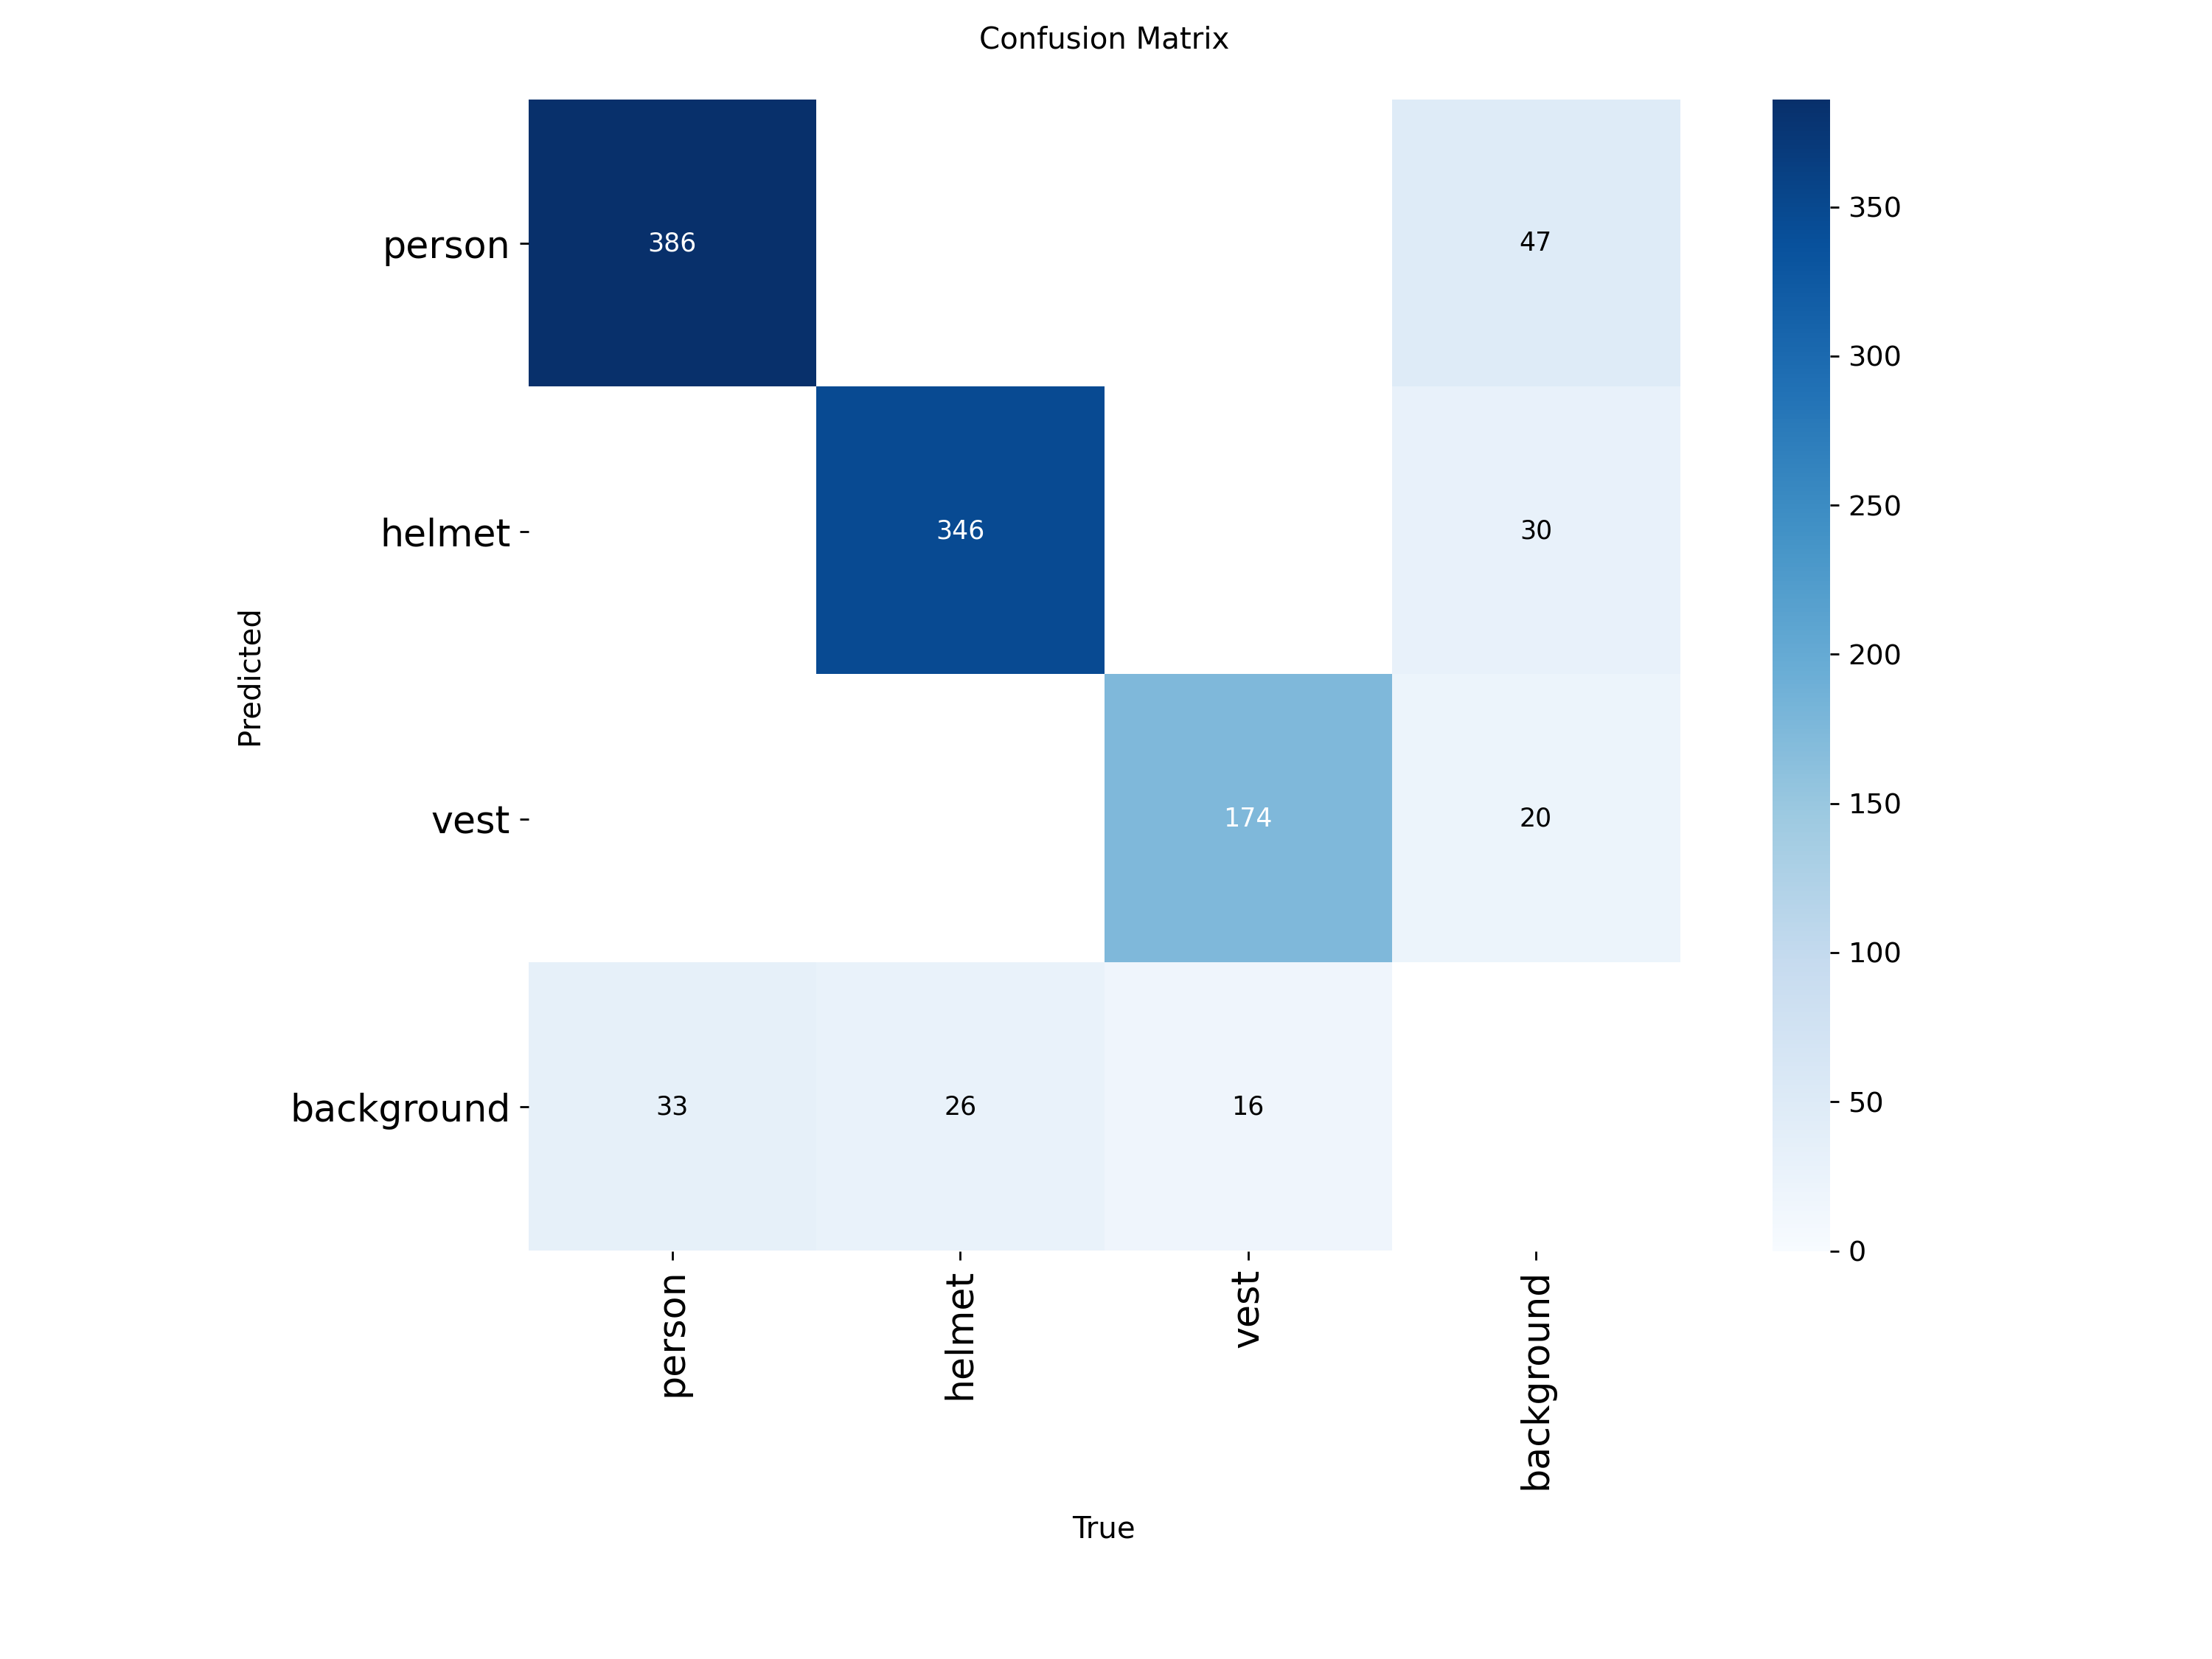


--- Validation normalized confusion matrix ---


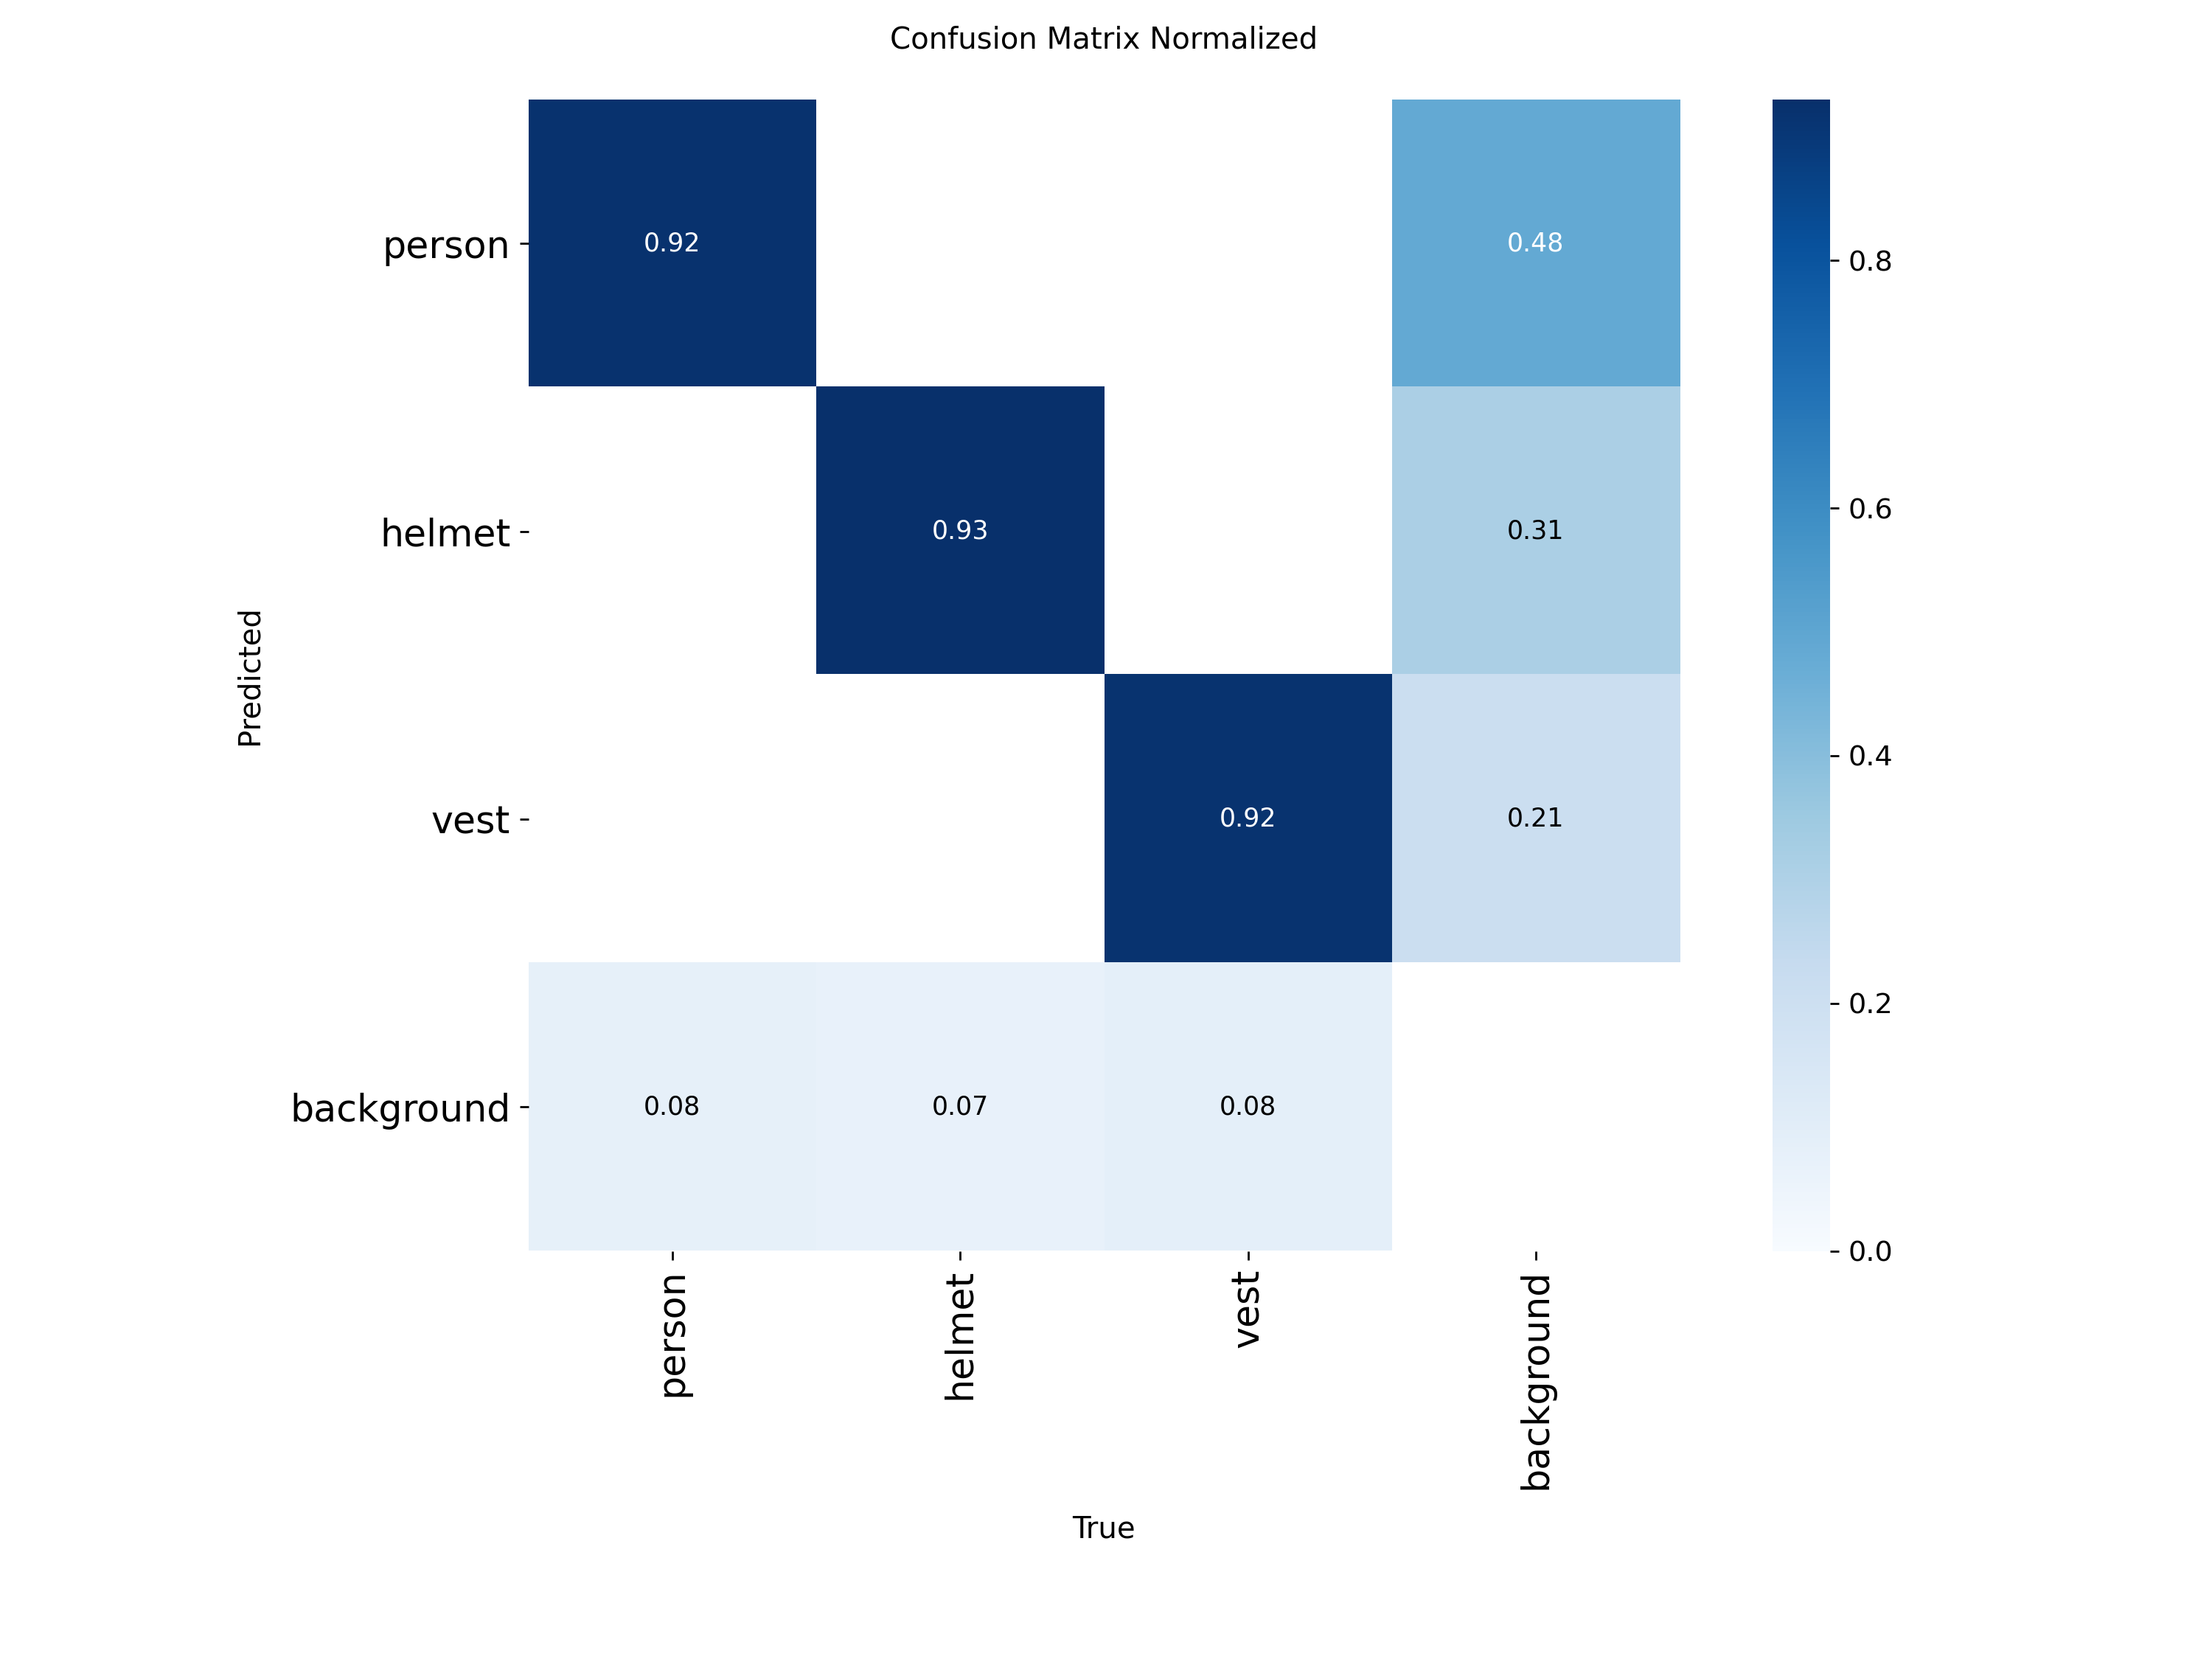


--- Validation PR curve ---
Missing: /content/runs/detect/yolov8m_ppe_v1_es_val/PR_curve.png

--- Validation F1 curve ---
Missing: /content/runs/detect/yolov8m_ppe_v1_es_val/F1_curve.png

--- Validation precision curve ---
Missing: /content/runs/detect/yolov8m_ppe_v1_es_val/P_curve.png

--- Validation recall curve ---
Missing: /content/runs/detect/yolov8m_ppe_v1_es_val/R_curve.png

--- Validation sample predictions ---


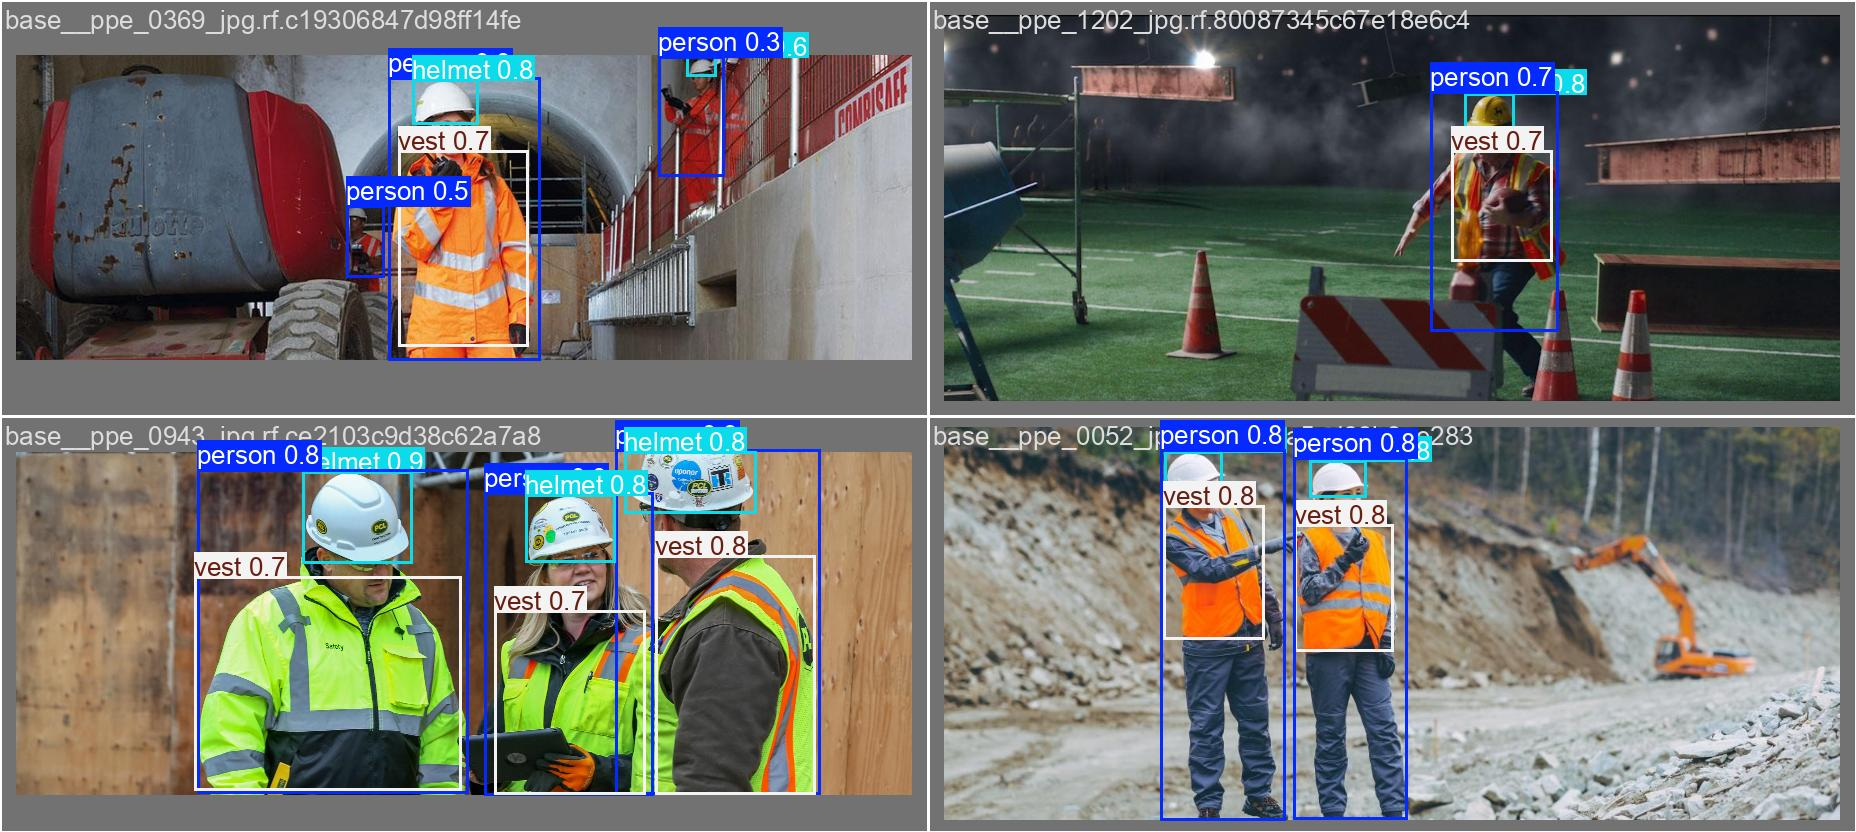


--- Validation sample labels ---


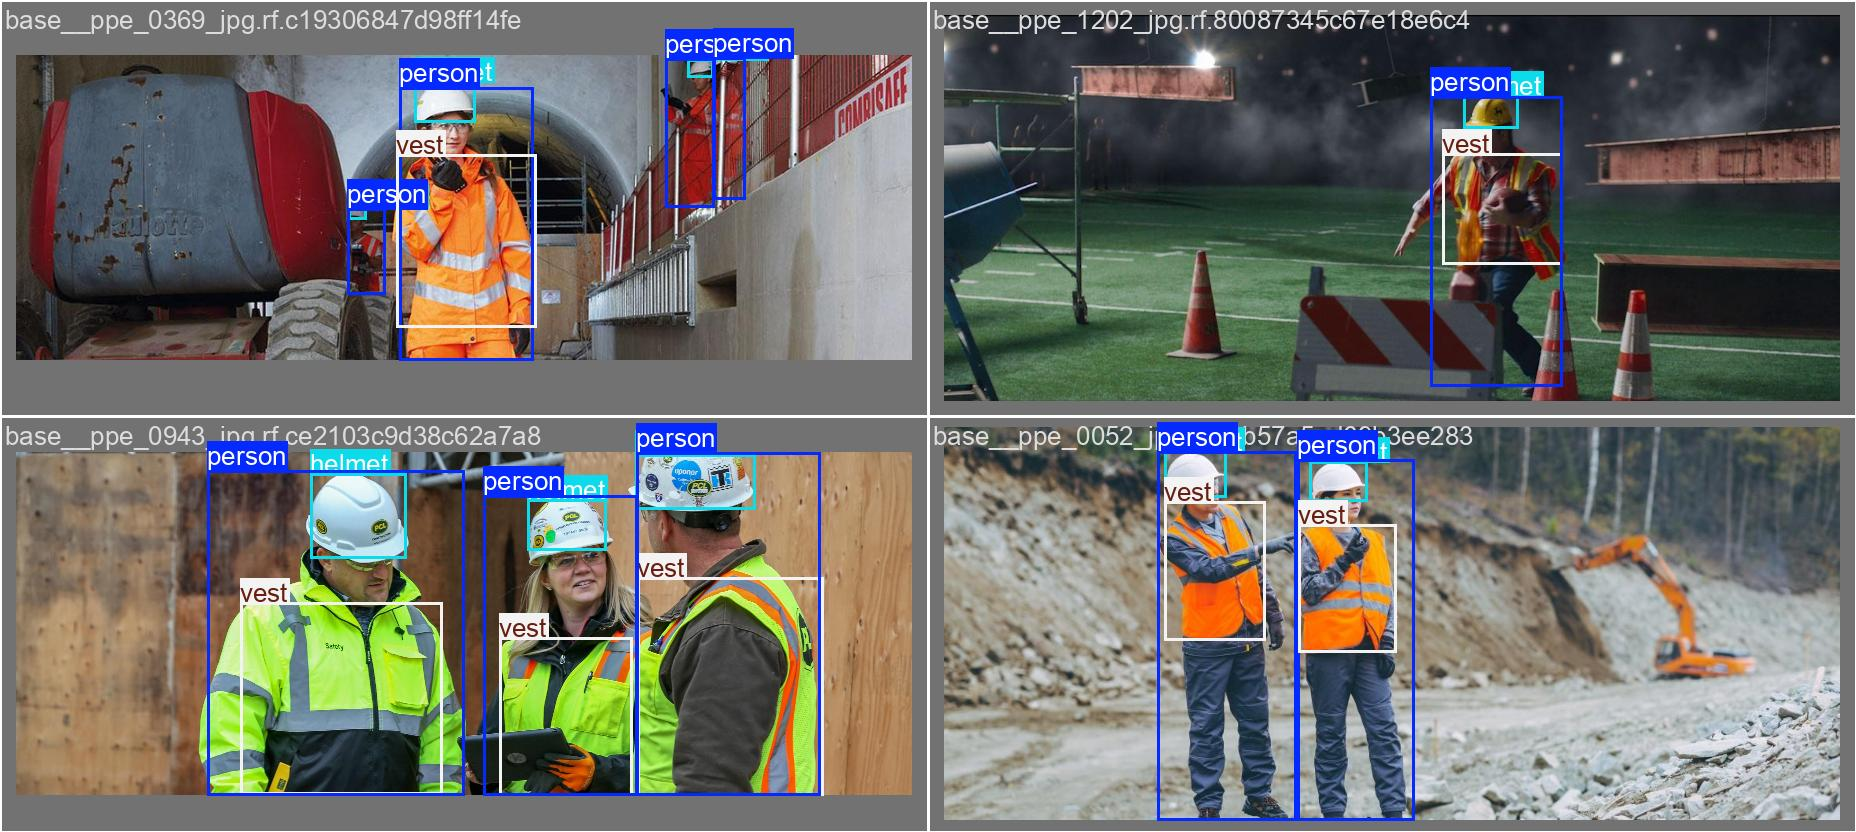

In [16]:
from IPython.display import Image as IPyImage, display

def display_image_if_exists(path, width=900):
    path = Path(path)
    if path.exists():
        display(IPyImage(filename=str(path), width=width))
    else:
        print("Missing:", path)

artifact_list = [
    ("Training summary plot", TRAIN_RUN_DIR / "results.png"),
    ("Validation confusion matrix", VAL_RUN_DIR / "confusion_matrix.png"),
    ("Validation normalized confusion matrix", VAL_RUN_DIR / "confusion_matrix_normalized.png"),
    ("Validation PR curve", VAL_RUN_DIR / "PR_curve.png"),
    ("Validation F1 curve", VAL_RUN_DIR / "F1_curve.png"),
    ("Validation precision curve", VAL_RUN_DIR / "P_curve.png"),
    ("Validation recall curve", VAL_RUN_DIR / "R_curve.png"),
    ("Validation sample predictions", VAL_RUN_DIR / "val_batch0_pred.jpg"),
    ("Validation sample labels", VAL_RUN_DIR / "val_batch0_labels.jpg"),
]

for title, path in artifact_list:
    print(f"\n--- {title} ---")
    display_image_if_exists(path)

Save final model artifacts and make them downloadable

In [17]:
EXPORT_DIR = Path("/content/final_model_artifacts")
if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    BEST_WEIGHTS,
    LAST_WEIGHTS if LAST_WEIGHTS.exists() else None,
    Path(YAML_PATH),
    TRAIN_RUN_DIR / "results.csv",
    TRAIN_RUN_DIR / "results.png",
    Path("/content/dataset_stats.csv"),
    Path("/content/evaluation_overall.csv"),
    Path("/content/evaluation_per_class_val.csv"),
    Path("/content/evaluation_per_class_test.csv") if test_metrics is not None else None,
]

for src in files_to_copy:
    if src is not None and Path(src).exists():
        shutil.copy2(src, EXPORT_DIR / Path(src).name)

image_artifacts = [
    VAL_RUN_DIR / "confusion_matrix.png",
    VAL_RUN_DIR / "confusion_matrix_normalized.png",
    VAL_RUN_DIR / "PR_curve.png",
    VAL_RUN_DIR / "F1_curve.png",
    VAL_RUN_DIR / "P_curve.png",
    VAL_RUN_DIR / "R_curve.png",
    VAL_RUN_DIR / "val_batch0_pred.jpg",
    VAL_RUN_DIR / "val_batch0_labels.jpg",
]

for src in image_artifacts:
    if Path(src).exists():
        shutil.copy2(src, EXPORT_DIR / Path(src).name)

run_summary = {
    "run_name": RUN_NAME,
    "model_name": MODEL_NAME,
    "image_size": IMGSZ,
    "epochs": EPOCHS,
    "dataset_root": str(DATASET_ROOT),
    "best_weights": str(BEST_WEIGHTS),
    "last_weights": str(LAST_WEIGHTS),
    "train_run_dir": str(TRAIN_RUN_DIR),
    "val_run_dir": str(VAL_RUN_DIR),
    "test_run_dir": str(TEST_RUN_DIR) if TEST_RUN_DIR else None,
}

with open(EXPORT_DIR / "run_summary.json", "w") as f:
    json.dump(run_summary, f, indent=2)

ARTIFACT_ZIP = shutil.make_archive(
    base_name=f"/content/{RUN_NAME}_artifacts",
    format="zip",
    root_dir=EXPORT_DIR
)

print("Export directory:", EXPORT_DIR)
print("Best model saved at:", EXPORT_DIR / BEST_WEIGHTS.name)
print("Last model saved at:", EXPORT_DIR / LAST_WEIGHTS.name)
print("Artifacts zip:", ARTIFACT_ZIP)

Export directory: /content/final_model_artifacts
Best model saved at: /content/final_model_artifacts/best.pt
Last model saved at: /content/final_model_artifacts/last.pt
Artifacts zip: /content/yolov8m_ppe_v1_es_artifacts.zip


Download the trained model files

In [18]:
try:
    from google.colab import files

    best_pt_for_download = EXPORT_DIR / BEST_WEIGHTS.name
    last_pt_for_download = EXPORT_DIR / LAST_WEIGHTS.name

    if best_pt_for_download.exists():
        files.download(str(best_pt_for_download))

    if last_pt_for_download.exists():
        files.download(str(last_pt_for_download))

    if Path(ARTIFACT_ZIP).exists():
        files.download(str(ARTIFACT_ZIP))

except Exception as e:
    print("Automatic download works only inside Google Colab.")
    print("Manually download these from the Files panel:")
    print(" -", EXPORT_DIR / BEST_WEIGHTS.name)
    print(" -", EXPORT_DIR / LAST_WEIGHTS.name)
    print(" -", ARTIFACT_ZIP)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>